# 04 — Statistical Analysis & Hypothesis Testing
**NST DVA Capstone 2 | B_G6_DIGITOMICS**

**Sector:** EdTech / Digital Behaviour Analytics  
**Dataset:** Student Digital Behaviour Data  
**Notebook Purpose:** Rigorously test relationships identified in EDA using correlation metrics, regression models, and hypothesis testing.

---
## Pipeline Steps:
1. Correlation Matrix
2. Hypothesis Testing (T-tests / ANOVA)
3. Regression Analysis


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded for Statistical Analysis.")

Libraries loaded for Statistical Analysis.


In [2]:
# Load the cleaned dataset
PROCESSED_PATH = '../data/processed/student_digital_behaviour_cleaned.csv'
df = pd.read_csv(PROCESSED_PATH)

# Ensuring student_id is index if not already
if 'student_id' in df.columns:
    df.set_index('student_id', inplace=True)


## 1. Correlation Analysis
Identifying linear correlations between key behavioral metrics and outcomes.

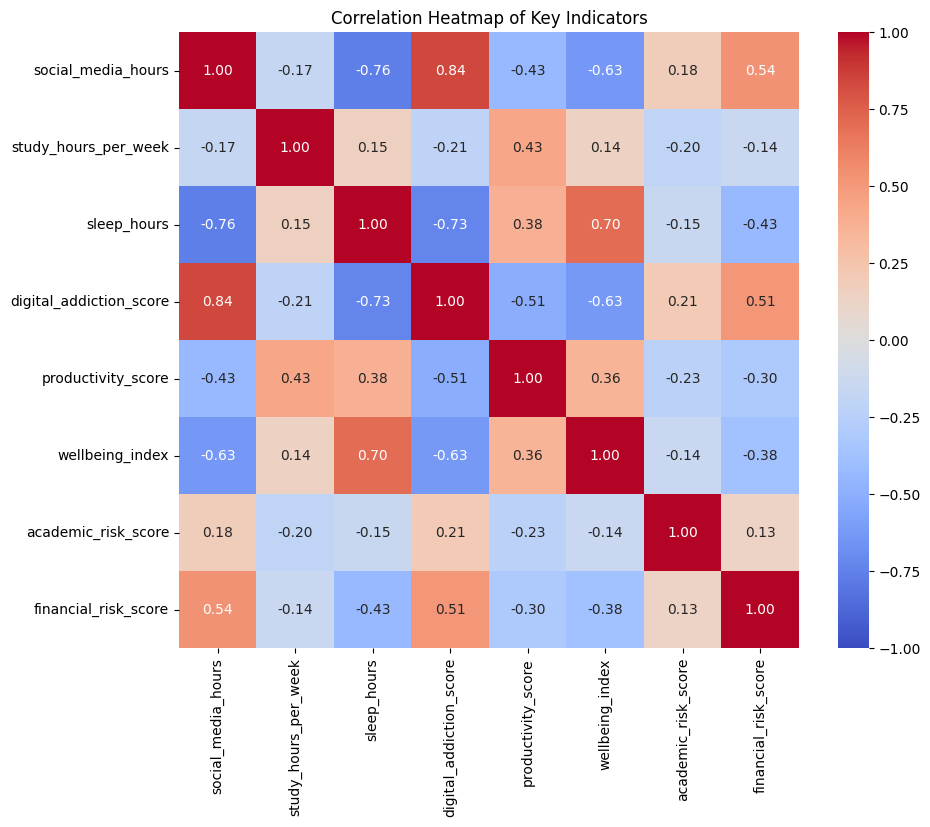

In [3]:
# Select continuous variables for correlation
cols_of_interest = ['social_media_hours', 'study_hours_per_week', 'sleep_hours', 
                    'digital_addiction_score', 'productivity_score', 'wellbeing_index', 
                    'academic_risk_score', 'financial_risk_score']

# Ensure numeric types
for col in cols_of_interest:
    df[col] = pd.to_numeric(df[col], errors='coerce')

corr_matrix = df[cols_of_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Indicators')
plt.show()

**Correlation Insights:**
- Check the negative correlation between `digital_addiction_score` and `productivity_score`.
- Positive correlation expected between `social_media_hours` and `academic_risk_score`.

## 2. Hypothesis Testing
**Hypothesis 1:** Urban students have a higher digital addiction score than rural students.
- **Null Hypothesis (H0):** Mean digital addiction score is identical for Urban and Rural students.
- **Alternative Hypothesis (H1):** Mean differs significantly.


In [4]:
urban_scores = df[df['urban_rural'] == 'Urban']['digital_addiction_score'].dropna()
rural_scores = df[df['urban_rural'] == 'Rural']['digital_addiction_score'].dropna()

if len(urban_scores) > 0 and len(rural_scores) > 0:
    t_stat, p_value = stats.ttest_ind(urban_scores, rural_scores, equal_var=False)

    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4e}")

    if p_value < 0.05:
        print("Conclusion: Reject the Null Hypothesis. There is a statistically significant difference.")
    else:
        print("Conclusion: Fail to reject the Null Hypothesis. No significant difference found.")
else:
    print("Not enough data to perform the test.")

T-statistic: 72.5210
P-value: 0.0000e+00
Conclusion: Reject the Null Hypothesis. There is a statistically significant difference.


## 3. Regression Analysis
**Objective:** Predict `academic_risk_score` based on screen time and behavior.

In [5]:
# Define features (X) and target (y)
X = df[['social_media_hours', 'short_video_hours', 'digital_addiction_score', 'late_night_score']].dropna()
y = df.loc[X.index, 'academic_risk_score']

# Add constant for statsmodels
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X, missing='drop')
results = model.fit()

print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     academic_risk_score   R-squared:                       0.047
Model:                             OLS   Adj. R-squared:                  0.047
Method:                  Least Squares   F-statistic:                     6175.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         17:08:38   Log-Likelihood:            -5.8352e+05
No. Observations:               500000   AIC:                         1.167e+06
Df Residuals:                   499995   BIC:                         1.167e+06
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const           

**Regression Insights:**
- Based on the P>|t| values, we can determine which factors most strongly drive academic risk.
- R-squared indicates the percentage of variance explained by our model.
